In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



In [37]:
# Load the dataset
file_path = "C:/Users/16172/Downloads/Netflix_Modeling.csv"  # Update the path to your dataset
netflix_data = pd.read_csv(file_path)
head=netflix_data.head()
print(head)

   User ID      Date       Day             Show  Season  Episode  \
0    62565  2/9/2019  Saturday  Stranger Things     2.0     10.0   
1   108824  2/9/2019  Saturday  Stranger Things     1.0      4.0   
2   118833  2/9/2019  Saturday  Stranger Things     2.0      8.0   
3    97717  2/9/2019  Saturday  Stranger Things     2.0      6.0   
4    35588  2/9/2019  Saturday  Stranger Things     2.0     10.0   

   Time Watched  Gender  Completed  Time of Day  
0          59.0  Female        1.0          1.0  
1          40.0  Female        0.0          1.0  
2          51.0    Male        1.0          1.0  
3          10.0    Male        0.0          0.0  
4          40.0  Female        1.0          1.0  


In [ ]:
# Convert 'Date' column to datetime datatype
netflix_data['Date'] = pd.to_datetime(netflix_data['Date'])


In [38]:
missing_count= netflix_data.isnull().sum()
print(missing_count)

User ID           0
Date              0
Day               0
Show              0
Season           35
Episode          18
Time Watched     17
Gender           99
Completed        47
Time of Day     100
dtype: int64


In [39]:
# Data Cleaning
# Fill missing values for numerical columns with median
netflix_data['Season'].fillna(netflix_data['Season'].median(), inplace=True)
netflix_data['Episode'].fillna(netflix_data['Episode'].median(), inplace=True)
netflix_data['Time Watched'].fillna(netflix_data['Time Watched'].median(), inplace=True)
netflix_data['Time of Day'].fillna(netflix_data['Time of Day'].median(), inplace=True)

In [40]:
# Fill missing values for categorical columns with mode
netflix_data['Gender'].fillna(netflix_data['Gender'].mode()[0], inplace=True)
netflix_data['Completed'].fillna(netflix_data['Completed'].mode()[0], inplace=True)

In [41]:
# Preparing the data for modeling
X = netflix_data.drop('Completed', axis=1)
y = netflix_data['Completed']

In [42]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [44]:
# OneHotEncode categorical data
categorical_features = ['Day', 'Show', 'Gender']
numerical_features = ['Season', 'Episode', 'Time Watched', 'Time of Day']

preprocessor = ColumnTransformer(
    transformers=[
       ('num', StandardScaler(), numerical_features),
       ('cat', OneHotEncoder(), categorical_features)
    ])

In [45]:
# Model 1: Multiple Logistic Regression (All Variables)
logreg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('classifier', LogisticRegression())])
logreg_pipeline.fit(X_train, y_train)
logreg_predictions = logreg_pipeline.predict(X_test)
logreg_accuracy = accuracy_score(y_test, logreg_predictions)

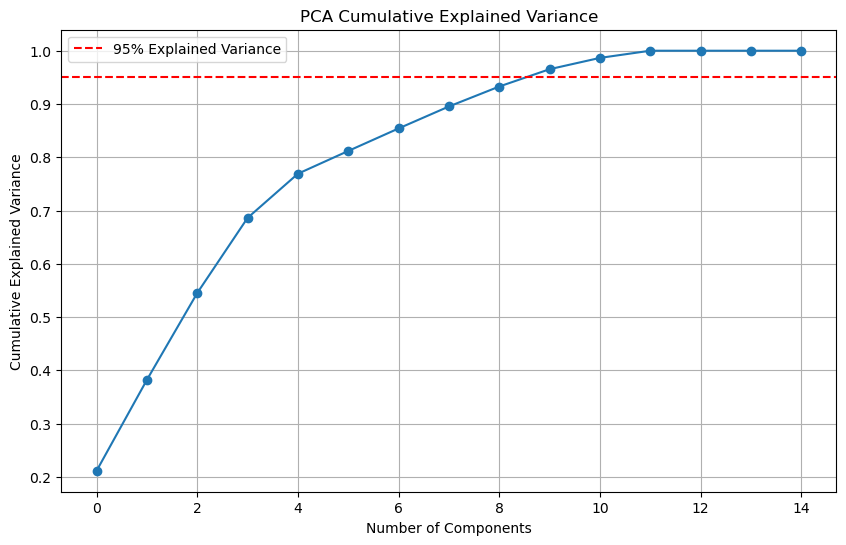

Optimal number of PCA components: 10


In [51]:
# Apply preprocessing steps to the training data for pca
X_train_transformed = preprocessor.fit_transform(X_train)

# Run PCA and determine the explained variance
pca = PCA().fit(X_train_transformed)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the cumulative variance graph
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# Determine the number of components for 95% variance
n_components_optimal = np.argmax(cumulative_variance >= 0.95) + 1
print("Optimal number of PCA components:", n_components_optimal)

In [52]:
# pipeline with the optimal number of PCA components and applying regression model
pca_logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=n_components_optimal)),
    ('classifier', LogisticRegression())
])

# Fit and predict with the updated pipeline
pca_logreg_pipeline.fit(X_train, y_train)
pca_logreg_predictions = pca_logreg_pipeline.predict(X_test)
pca_logreg_accuracy = accuracy_score(y_test, pca_logreg_predictions)
print("Accuracy of Logistic Regression with PCA:", pca_logreg_accuracy)


Accuracy of Logistic Regression with PCA: 0.9135254988913526


In [53]:
# Model 3: Decision Tree (All Variables)
tree_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', DecisionTreeClassifier())])
tree_pipeline.fit(X_train, y_train)
tree_predictions = tree_pipeline.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_predictions)

In [54]:
# Print results
print("Logistic Regression Accuracy:", logreg_accuracy)
print("Logistic Regression with PCA Accuracy:", pca_logreg_accuracy)
print("Decision Tree Accuracy:", tree_accuracy)

print("\nLogistic Regression Report:\n", classification_report(y_test, logreg_predictions))
print("\nLogistic Regression with PCA Report:\n", classification_report(y_test, pca_logreg_predictions))
print("\nDecision Tree Report:\n", classification_report(y_test, tree_predictions))

Logistic Regression Accuracy: 0.9434589800443459
Logistic Regression with PCA Accuracy: 0.9135254988913526
Decision Tree Accuracy: 0.9722838137472284

Logistic Regression Report:
               precision    recall  f1-score   support

         0.0       0.95      0.97      0.96       664
         1.0       0.92      0.86      0.89       238

    accuracy                           0.94       902
   macro avg       0.94      0.92      0.93       902
weighted avg       0.94      0.94      0.94       902


Logistic Regression with PCA Report:
               precision    recall  f1-score   support

         0.0       0.93      0.96      0.94       664
         1.0       0.87      0.79      0.83       238

    accuracy                           0.91       902
   macro avg       0.90      0.87      0.89       902
weighted avg       0.91      0.91      0.91       902


Decision Tree Report:
               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     

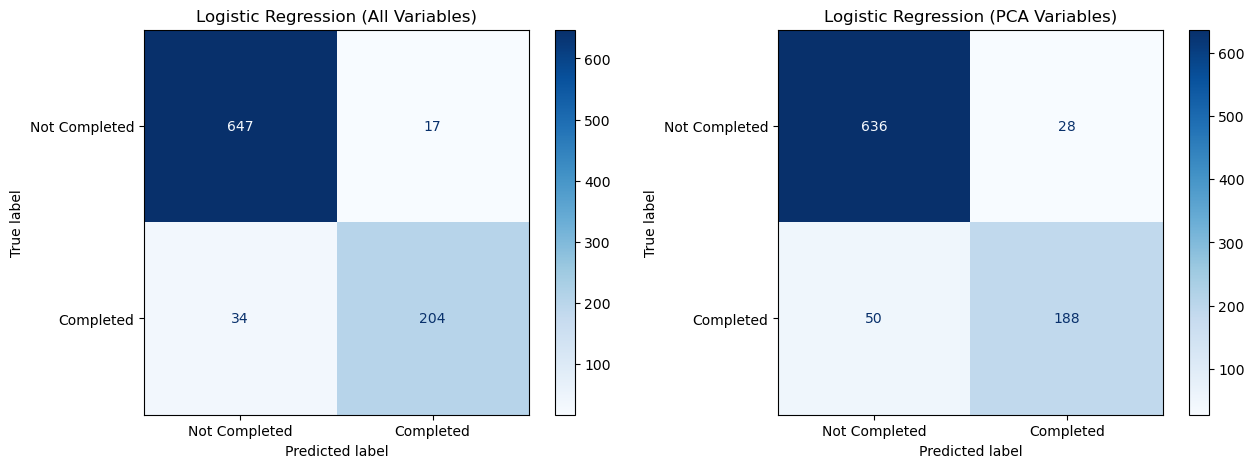

In [55]:

# Predictions from the logistic regression models
logreg_predictions = logreg_pipeline.predict(X_test)
pca_logreg_predictions = pca_logreg_pipeline.predict(X_test)

# Generating confusion matrices for the logistic regression models
confusion_matrix_logreg = confusion_matrix(y_test, logreg_predictions)
confusion_matrix_pca_logreg = confusion_matrix(y_test, pca_logreg_predictions)

# Plotting the confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix for Logistic Regression (All Variables)
ConfusionMatrixDisplay(confusion_matrix_logreg, display_labels=['Not Completed', 'Completed']).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Logistic Regression (All Variables)')

# Confusion matrix for Logistic Regression with PCA
ConfusionMatrixDisplay(confusion_matrix_pca_logreg, display_labels=['Not Completed', 'Completed']).plot(ax=ax[1], cmap='Blues')
ax[1].set_title('Logistic Regression (PCA Variables)')

plt.show()


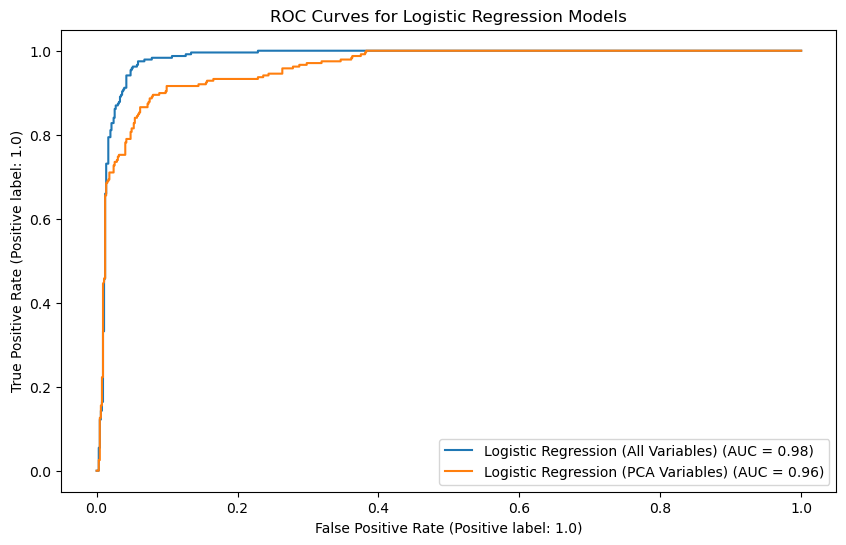

In [56]:
# ROC Curves for Logistic Regression Models
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting ROC for Logistic Regression (All Variables)
RocCurveDisplay.from_estimator(logreg_pipeline, X_test, y_test, ax=ax, name='Logistic Regression (All Variables)')

# Plotting ROC for Logistic Regression with PCA
RocCurveDisplay.from_estimator(pca_logreg_pipeline, X_test, y_test, ax=ax, name='Logistic Regression (PCA Variables)')

plt.title("ROC Curves for Logistic Regression Models")
plt.show()

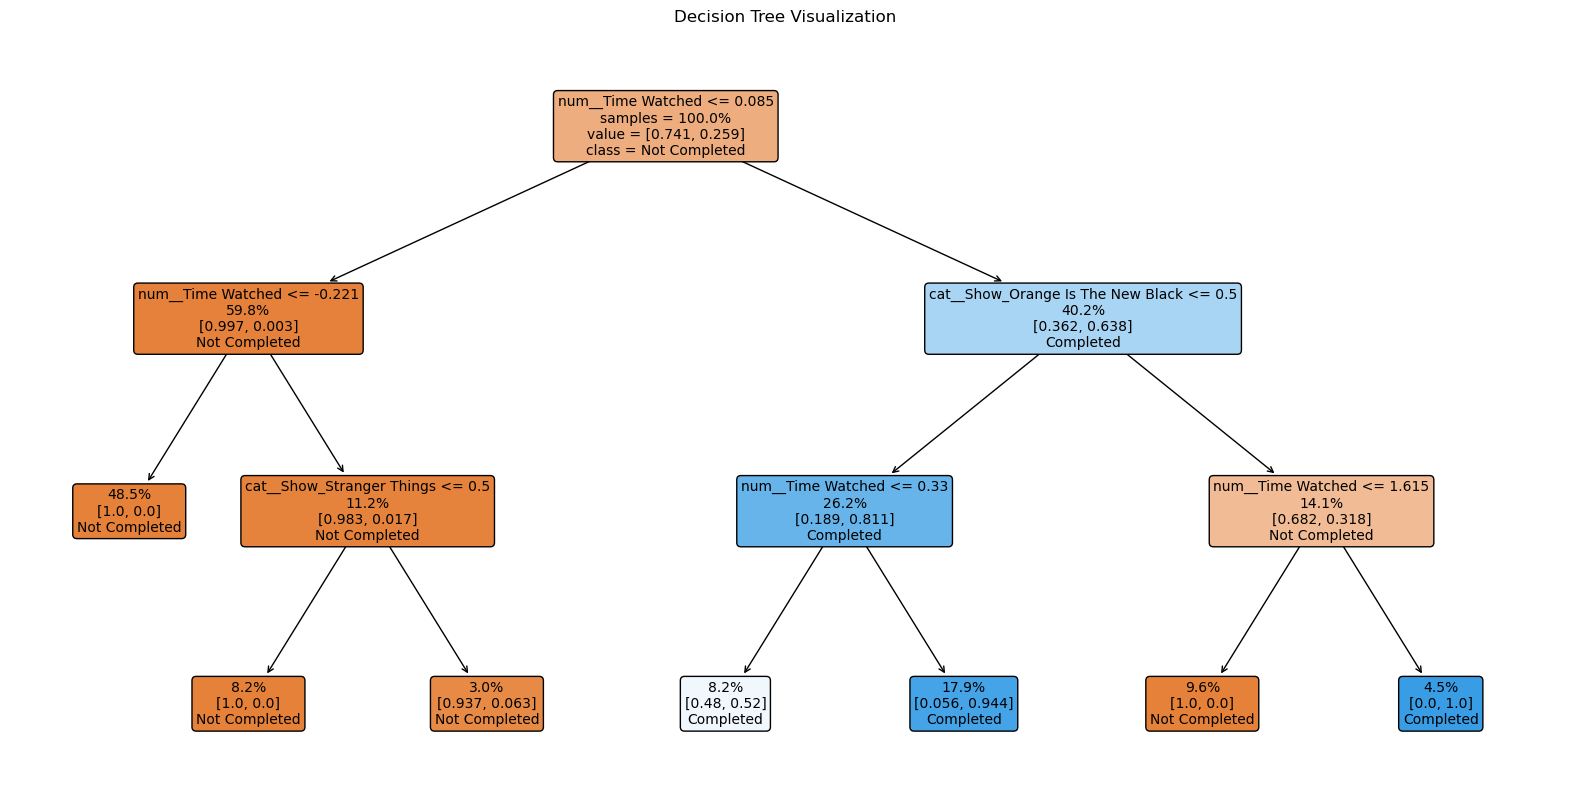

In [57]:
# Rebuilding the Decision Tree model with a simple representation
tree_model_simple = DecisionTreeClassifier(max_depth=3)
tree_model_simple.fit(preprocessor.fit_transform(X_train), y_train)

# Convert feature names to a list
feature_names = preprocessor.get_feature_names_out().tolist()


# Plotting the simplified Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(tree_model_simple, filled=True, feature_names=feature_names, rounded=True, 
          class_names=['Not Completed', 'Completed'], 
          label='root', proportion=True, impurity=False, fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

